In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt


In [ ]:
class TrafficEnvironment:
    def __init__(self):
        self.state = [random.randint(0, 10), random.randint(0, 10)]

    def reset(self):

        self.state = [random.randint(0, 10), random.randint(0, 10)]
        return self.state

    def step(self, action):
        ns, ew = self.state

       if action == 0:
            ns = max(0, ns - random.randint(1, 5))
            ew += random.randint(0, 3)
        else:
            ew = max(0, ew - random.randint(1, 5))
            ns += random.randint(0, 3)


        waiting_time = ns + ew
        reward = -waiting_time

        self.state = [ns, ew]
        return self.state, reward


In [ ]:
q_table = np.zeros((11, 11, 2))

alpha = 0.1
gamma = 0.9
epsilon = 1.0
episodes = 50

env = TrafficEnvironment()



In [ ]:
waiting_times = []

for episode in range(episodes):
    state = env.reset()
    total_wait = 0
    done = False

    while not done:

        if random.uniform(0, 1) > epsilon:
            action = np.argmax(q_table[state[0], state[1], :])
        else:
            action = random.choice([0, 1])

        next_state, reward = env.step(action)
        done = False

       next_state = np.clip(next_state, 0, 10)

       old_value = q_table[state[0], state[1], action]
        next_max = np.max(q_table[next_state[0], next_state[1], :])
        q_table[state[0], state[1], action] = (1 - alpha) * old_value + alpha * (reward + gamma * next_max)

        total_wait += -reward
        state = next_state

        if total_wait > 200:
            done = True

    waiting_times.append(total_wait)
    print(f"Episode {episode+1}: Total Waiting Time = {total_wait}")





Episode 1: Total Waiting Time = 214
Episode 2: Total Waiting Time = 202
Episode 3: Total Waiting Time = 204
Episode 4: Total Waiting Time = 203
Episode 5: Total Waiting Time = 201
Episode 6: Total Waiting Time = 208
Episode 7: Total Waiting Time = 203
Episode 8: Total Waiting Time = 202
Episode 9: Total Waiting Time = 201
Episode 10: Total Waiting Time = 214
Episode 11: Total Waiting Time = 205
Episode 12: Total Waiting Time = 205
Episode 13: Total Waiting Time = 204
Episode 14: Total Waiting Time = 201
Episode 15: Total Waiting Time = 201
Episode 16: Total Waiting Time = 204
Episode 17: Total Waiting Time = 201
Episode 18: Total Waiting Time = 204
Episode 19: Total Waiting Time = 204
Episode 20: Total Waiting Time = 203
Episode 21: Total Waiting Time = 207
Episode 22: Total Waiting Time = 208
Episode 23: Total Waiting Time = 207
Episode 24: Total Waiting Time = 204
Episode 25: Total Waiting Time = 202
Episode 26: Total Waiting Time = 212
Episode 27: Total Waiting Time = 203
Episode 28

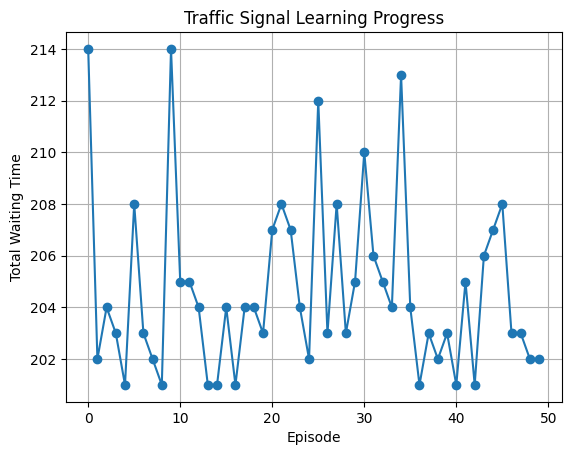

In [ ]:
plt.plot(waiting_times, marker='o')
plt.title("Traffic Signal Learning Progress")
plt.xlabel("Episode")
plt.ylabel("Total Waiting Time")
plt.grid(True)
plt.show()

